# Week 1 Practical Assignment — Python & Data Analysis Fundamentals

**Internship:** AI & ML Internship  
**Task:** Python for Data Science + CSV Data Analysis  
**Dataset:** Student Performance Dataset

### Objectives
- Load and inspect a CSV dataset using Pandas.
- Identify rows, columns and data types.
- Detect missing values and duplicate records.
- Perform basic data cleaning.
- Generate statistical insights.
- Create at least 3 visualizations using Matplotlib.


## 1. Import Required Libraries

We use:
- **Pandas** for data handling and analysis.
- **NumPy** for numerical operations.
- **Matplotlib** for data visualization.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline


Matplotlib is building the font cache; this may take a moment.


## 2. Load the CSV Dataset

In [2]:
df = pd.read_csv("student_performance.csv")

print("Dataset loaded successfully!")
df.head()


Dataset loaded successfully!


,Student_ID,Name,Gender,Age,Study_Hours,Attendance,Math_Score,Science_Score,English_Score
0,1,Aarav,Male,20,3.5,88,78,82.0,75
1,2,Ananya,Female,19,5.0,94,91,89.0,92
2,3,Rohan,Male,21,2.0,72,65,70.0,68
3,4,Priya,Female,20,4.5,91,84,88.0,86
4,5,Vivek,Male,22,1.5,65,58,NaN,60


## 3. Identify Number of Rows and Columns

In [3]:
rows, columns = df.shape

print("Number of rows:", rows)
print("Number of columns:", columns)
print("Dataset shape:", df.shape)


Number of rows: 51
Number of columns: 9
Dataset shape: (51, 9)


## 4. Analyze Dataset Structure and Data Types

In [4]:
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nDataset information:")
df.info()


Column names:
['Student_ID', 'Name', 'Gender', 'Age', 'Study_Hours', 'Attendance', 'Math_Score', 'Science_Score', 'English_Score']

Data types:
Student_ID         int64
Name                 str
Gender               str
Age                int64
Study_Hours      float64
Attendance         int64
Math_Score         int64
Science_Score    float64
English_Score      int64
dtype: object

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Student_ID     51 non-null     int64  
 1   Name           51 non-null     str    
 2   Gender         51 non-null     str    
 3   Age            51 non-null     int64  
 4   Study_Hours    50 non-null     float64
 5   Attendance     51 non-null     int64  
 6   Math_Score     51 non-null     int64  
 7   Science_Score  50 non-null     float64
 8   English_Score  51 non-null     int64  
dtypes: float64(2), 

## 5. Check for Missing Values

In [5]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

print("\nTotal missing values:", df.isnull().sum().sum())


Missing values in each column:
Student_ID       0
Name             0
Gender           0
Age              0
Study_Hours      1
Attendance       0
Math_Score       0
Science_Score    1
English_Score    0
dtype: int64

Total missing values: 2


## 6. Identify Duplicate Records

In [6]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

if duplicate_count > 0:
    print("\nDuplicate records:")
    display(df[df.duplicated(keep=False)])


Number of duplicate records: 1

Duplicate records:


,Student_ID,Name,Gender,Age,Study_Hours,Attendance,Math_Score,Science_Score,English_Score
9,10,Isha,Female,20,5.5,93,90,91.0,88
50,10,Isha,Female,20,5.5,93,90,91.0,88


## 7. Basic Data Cleaning

For this dataset:
1. Fill missing numeric values with the median of their respective columns.
2. Remove duplicate records.
3. Reset the index after cleaning.


In [7]:
# Fill missing numeric values with column medians
numeric_columns = ["Age", "Study_Hours", "Attendance",
                   "Math_Score", "Science_Score", "English_Score"]

for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

# Remove duplicate rows
df = df.drop_duplicates()

# Reset index
df = df.reset_index(drop=True)

print("Missing values after cleaning:")
print(df.isnull().sum())

print("\nDuplicate records after cleaning:", df.duplicated().sum())
print("\nCleaned dataset shape:", df.shape)


Missing values after cleaning:
Student_ID       0
Name             0
Gender           0
Age              0
Study_Hours      0
Attendance       0
Math_Score       0
Science_Score    0
English_Score    0
dtype: int64

Duplicate records after cleaning: 0

Cleaned dataset shape: (50, 9)


## 8. Generate Basic Statistical Insights

In [8]:
print("Statistical summary:")
display(df[numeric_columns].describe())


Statistical summary:


,Age,Study_Hours,Attendance,Math_Score,Science_Score,English_Score
count,50.00000,50.000000,50.000000,50.00000,50.000000,50.000000
mean,20.28000,3.705000,83.580000,77.30000,80.820000,78.500000
std,1.01096,1.305102,10.067304,11.22179,10.179391,11.321372
min,19.00000,1.000000,61.000000,55.00000,59.000000,57.000000
25%,19.25000,2.625000,76.250000,68.25000,73.250000,69.250000
50%,20.00000,3.625000,86.500000,79.00000,83.000000,79.000000
75%,21.00000,4.500000,91.750000,86.00000,89.000000,88.000000
max,22.00000,6.000000,98.000000,96.00000,96.000000,97.000000


In [9]:
print("Average study hours:", round(df["Study_Hours"].mean(), 2))
print("Average attendance:", round(df["Attendance"].mean(), 2))
print("Average Math score:", round(df["Math_Score"].mean(), 2))
print("Average Science score:", round(df["Science_Score"].mean(), 2))
print("Average English score:", round(df["English_Score"].mean(), 2))


Average study hours: 3.7
Average attendance: 83.58
Average Math score: 77.3
Average Science score: 80.82
Average English score: 78.5


In [10]:
# Average scores by gender
gender_scores = df.groupby("Gender")[["Math_Score", "Science_Score", "English_Score"]].mean()
display(gender_scores.round(2))


,Math_Score,Science_Score,English_Score
Gender,,,
Female,86.28,89.08,88.04
Male,68.32,72.56,68.96


In [11]:
# Student with the highest average subject score
df["Average_Score"] = df[["Math_Score", "Science_Score", "English_Score"]].mean(axis=1)

top_student = df.loc[df["Average_Score"].idxmax()]

print("Student with highest average score:")
print(top_student[["Name", "Gender", "Study_Hours", "Attendance", "Average_Score"]])


Student with highest average score:
Name              Aditi
Gender           Female
Study_Hours         6.0
Attendance           98
Average_Score      96.0
Name: 23, dtype: object


## 9. Visualization 1 — Average Math Score by Gender

A bar chart is useful for comparing categories.


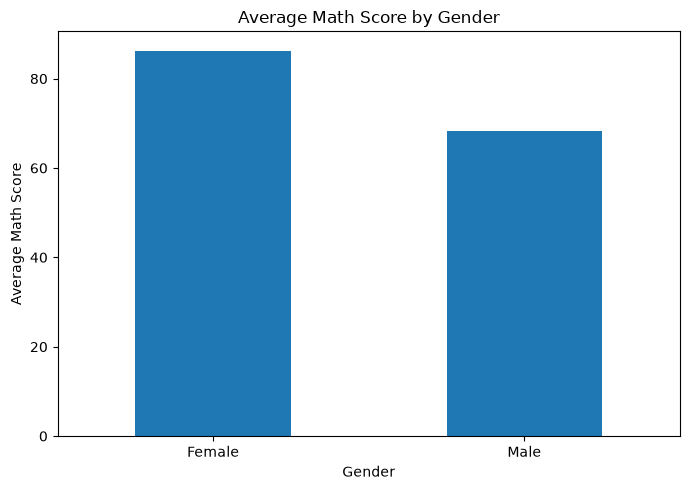

In [12]:
gender_math = df.groupby("Gender")["Math_Score"].mean()

plt.figure(figsize=(7, 5))
gender_math.plot(kind="bar")
plt.title("Average Math Score by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Math Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 10. Visualization 2 — Distribution of Study Hours

A histogram shows how study hours are distributed across students.


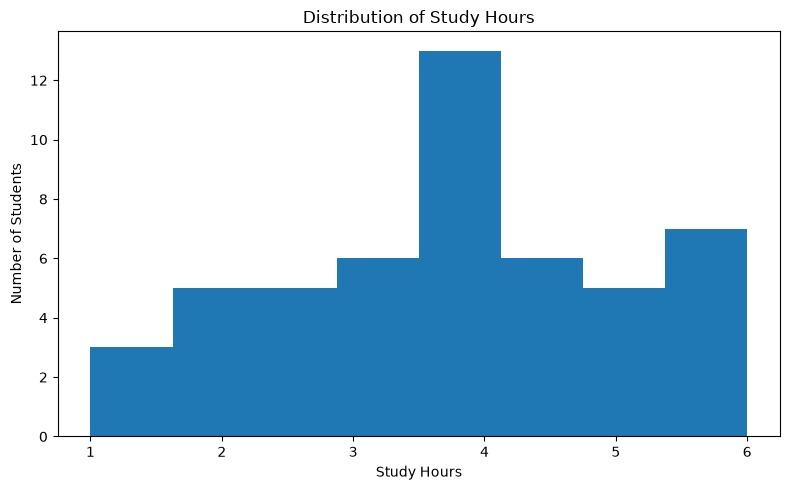

In [13]:
plt.figure(figsize=(8, 5))
plt.hist(df["Study_Hours"], bins=8)
plt.title("Distribution of Study Hours")
plt.xlabel("Study Hours")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.show()


## 11. Visualization 3 — Study Hours vs Math Score

A scatter plot helps us visually examine the relationship between study hours and Math scores.


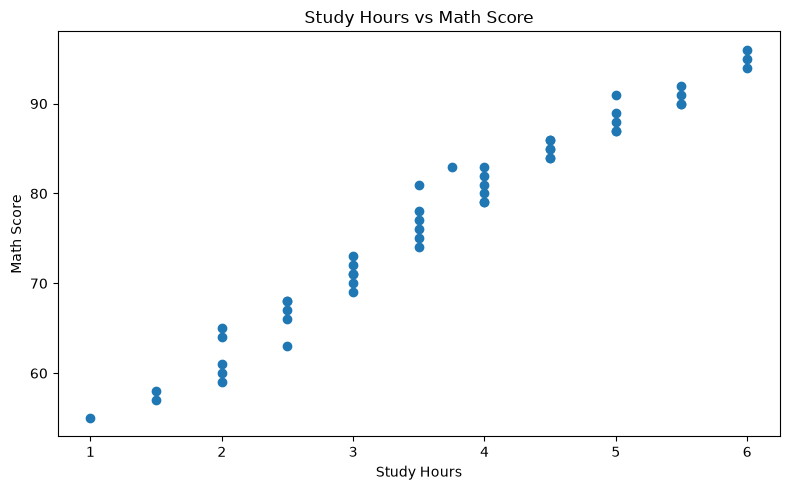

In [14]:
plt.figure(figsize=(8, 5))
plt.scatter(df["Study_Hours"], df["Math_Score"])
plt.title("Study Hours vs Math Score")
plt.xlabel("Study Hours")
plt.ylabel("Math Score")
plt.tight_layout()
plt.show()


## 12. Additional Visualization — Average Subject Scores

This visualization compares the average performance in the three subjects.


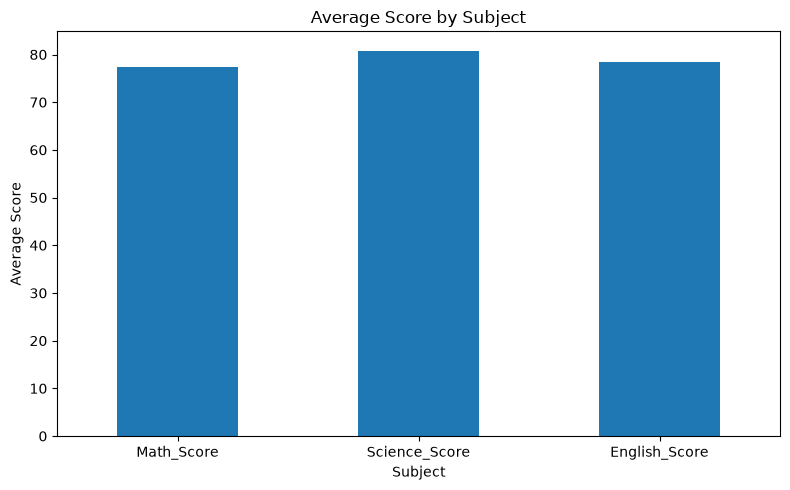

In [15]:
subject_averages = df[["Math_Score", "Science_Score", "English_Score"]].mean()

plt.figure(figsize=(8, 5))
subject_averages.plot(kind="bar")
plt.title("Average Score by Subject")
plt.xlabel("Subject")
plt.ylabel("Average Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 13. Save the Cleaned Dataset

The cleaned dataset is saved as a separate CSV file.


In [16]:
cleaned_path = "student_performance_cleaned.csv"

# Remove the analysis-only column before saving
df.drop(columns=["Average_Score"]).to_csv(cleaned_path, index=False)

print("Cleaned dataset saved as:", cleaned_path)


Cleaned dataset saved as: student_performance_cleaned.csv


## 14. Conclusion

The dataset was successfully loaded and analyzed using Python, Pandas, NumPy and Matplotlib.

### Key activities completed
- Loaded a CSV dataset.
- Checked rows and columns.
- Examined data types and structure.
- Detected missing values.
- Detected and removed duplicate records.
- Performed basic data cleaning.
- Generated statistical summaries.
- Created multiple data visualizations.

### Learning Outcome
This practical demonstrates the basic workflow used in data analysis: **Load → Inspect → Clean → Analyze → Visualize → Save**.
